In [3]:
# import sys
# print("Python version:", sys.version)

import pandas as pd
print("pandas version:", pd.__version__)

import matplotlib
print("matplotlib version:", matplotlib.__version__)

import numpy as np
print("NumPy version:", np.__version__)

# import scipy as sp
# print("SciPy version:", sp.__version__)

# import IPython
# print("IPython version:", IPython.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)

pandas version: 2.2.2
matplotlib version: 3.10.0
NumPy version: 2.0.2
scikit-learn version: 1.6.1


In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    cohen_kappa_score
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# считать датасет
from sklearn.datasets import load_iris
iris_dataset = load_iris()

print(iris_dataset.keys())
print(iris_dataset.target_names)
print(iris_dataset.feature_names)
print(iris_dataset.data[:3])
print(iris_dataset.target[:3])
iris_dataset.data.shape

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
[0 0 0]


(150, 4)

In [11]:
# объеденить в одну таблицу для чистоты понимания
df = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
df['target'] = iris_dataset.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
# общая информация, виден полный список колонок и пропуски в них
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [13]:
# распределение целевых классов
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


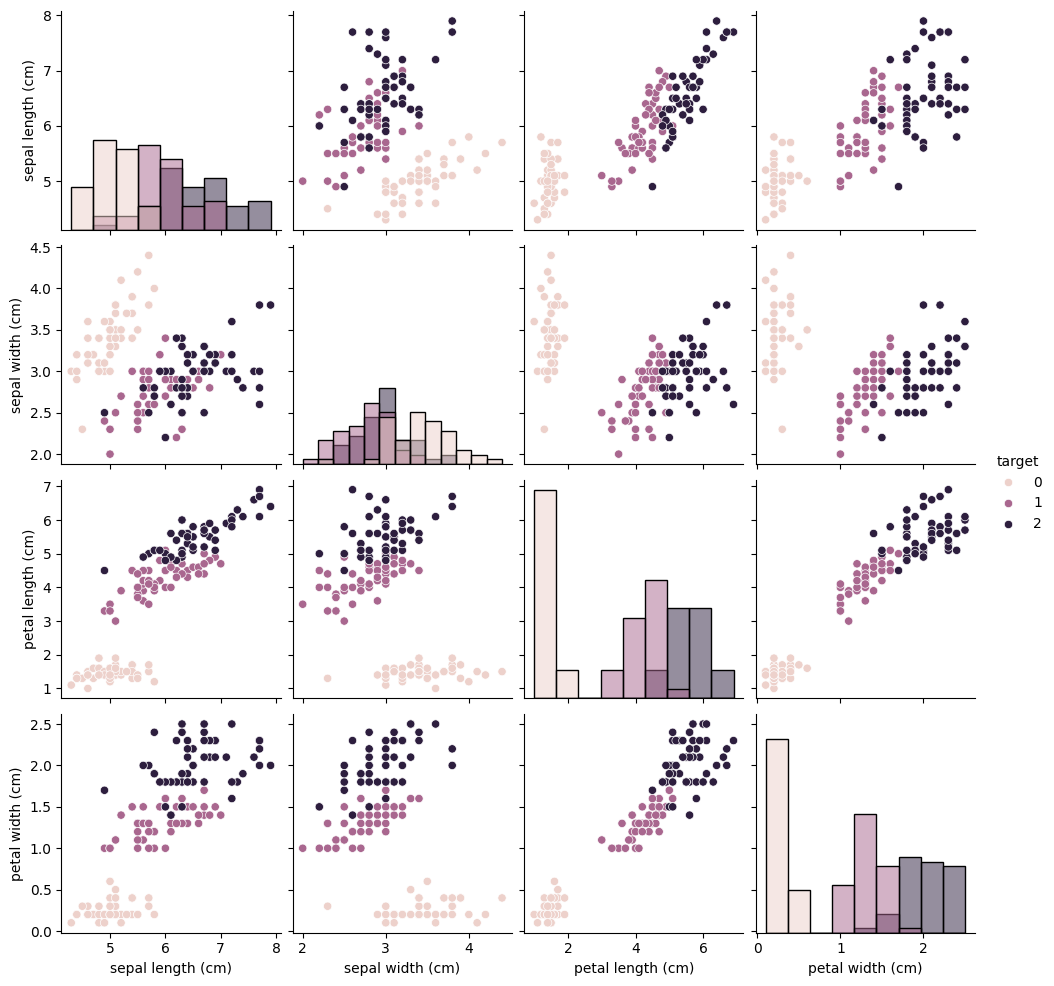

In [83]:
sns.pairplot(df, hue='target', diag_kind='hist')
# plt.show()

In [86]:
# РАЗОВАЯ разбивка на обучающую тестовую выборки
# случайно может дать "удачное" разбиение
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1)  # Все столбцы, кроме target
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    shuffle=True,
                                                    random_state=1)

In [87]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (120, 4)
y_train shape: (120,)


In [88]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (30, 4)
y_test shape: (30,)


## k-Nearest Neighbors

In [17]:
# from sklearn.neighbors import KNeighborsClassifier
# knn = KNeighborsClassifier(n_neighbors=1)

In [18]:
# knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [19]:
# X_new = np.array([[5, 2.9, 1, 0.2]])
# knn.predict(X_new)


array([0])

In [20]:
# y_pred = knn.predict(X_test)
# knn.score(X_test, y_test)

0.9777777777777777

#RandomForestClassifier

In [89]:
# 3. Обучение модели (Random Forest как пример)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Предсказания
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
model.score(X_test, y_test)

0.9666666666666667

In [85]:
#
# будет ли accuracy всегда 1.0 при разных random_state (разное разбиение на train-test?
#
accuracies = []

for seed in range(20):  # 20 разных разбиений
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, shuffle=True, random_state=seed
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    accuracies.append(acc)
    print(f"seed={seed:2d}, accuracy={acc:.2f}")

print(f"\nСредняя accuracy: {np.mean(accuracies):.2f}")
print(f"Минимальная: {np.min(accuracies):.2f}")
print(f"Максимальная: {np.max(accuracies):.2f}")
print(f"Разброс: {np.std(accuracies):.2f}")

seed= 0, accuracy=1.00
seed= 1, accuracy=0.97
seed= 2, accuracy=0.97
seed= 3, accuracy=0.90
seed= 4, accuracy=1.00
seed= 5, accuracy=0.97
seed= 6, accuracy=0.93
seed= 7, accuracy=1.00
seed= 8, accuracy=0.93
seed= 9, accuracy=0.97
seed=10, accuracy=1.00
seed=11, accuracy=1.00
seed=12, accuracy=1.00
seed=13, accuracy=1.00
seed=14, accuracy=0.97
seed=15, accuracy=0.90
seed=16, accuracy=1.00
seed=17, accuracy=0.97
seed=18, accuracy=0.90
seed=19, accuracy=1.00

Средняя accuracy: 0.97
Минимальная: 0.90
Максимальная: 1.00
Разброс: 0.04


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]



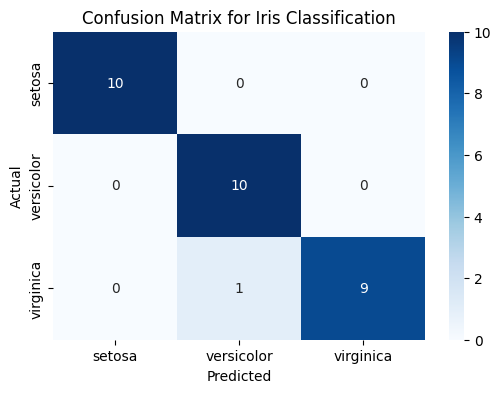

In [90]:
# 4.1 Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("=" * 60)
print("Confusion Matrix:")
print(cm)
print()

# Визуализация матрицы ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=iris_dataset.target_names,
            yticklabels=iris_dataset.target_names
)
plt.title('Confusion Matrix for Iris Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [91]:
# 4.2 Основные метрики
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

kappa = cohen_kappa_score(y_test, y_pred)

print("=" * 60)
print("ОСНОВНЫЕ МЕТРИКИ КЛАССИФИКАЦИИ:")
print(f"Accuracy: {accuracy:.2}")
print()
print(f"Precision (macro): {precision_macro:.2}")
print(f"Precision (micro): {precision_micro:.2}")
print(f"Precision (weighted): {precision_weighted:.2}")
print()
print(f"Recall (macro): {recall_macro:.2}")
print(f"Recall (micro): {recall_micro:.2}")
print(f"Recall (weighted): {recall_weighted:.2}")
print()
print(f"F1-Score (macro): {f1_macro:.2}")
print(f"F1-Score (micro): {f1_micro:.2}")
print(f"F1-Score (weighted): {f1_weighted:.2}")
print()
print(f"Cohen's Kappa: {kappa:.4f}")

ОСНОВНЫЕ МЕТРИКИ КЛАССИФИКАЦИИ:
Accuracy: 0.97

Precision (macro): 0.97
Precision (micro): 0.97
Precision (weighted): 0.97

Recall (macro): 0.97
Recall (micro): 0.97
Recall (weighted): 0.97

F1-Score (macro): 0.97
F1-Score (micro): 0.97
F1-Score (weighted): 0.97

Cohen's Kappa: 0.9500


In [92]:
# 4.4 Полный отчет по каждому классу
print("\n" + "=" * 60)
print("ПОДРОБНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print(classification_report(y_test, y_pred, target_names=iris_dataset.target_names))


ПОДРОБНЫЙ ОТЧЕТ ПО КЛАССАМ:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30




Feature Importance (from Random Forest):
             feature  importance
2  petal length (cm)    0.463049
3   petal width (cm)    0.392430
0  sepal length (cm)    0.117879
1   sepal width (cm)    0.026642


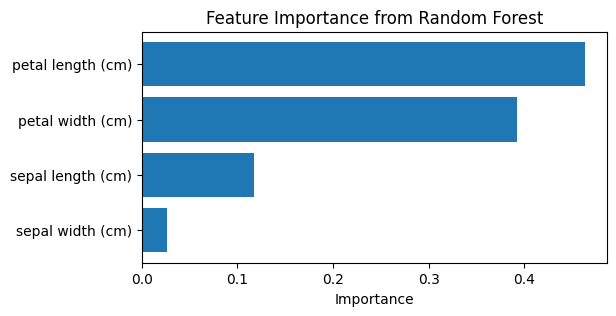

In [93]:
# 5.1 Важность признаков из модели (для Random Forest)
feature_importance = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (from Random Forest):")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(6, 3))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [94]:
#
# мудреный статистический тест, потом разобраться
#
# 5.2 ANOVA F-тест (линейная зависимость)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_train, y_train)
f_scores = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'f_score': selector_f.scores_,
    'p_value': selector_f.pvalues_
}).sort_values('f_score', ascending=False)

print("\nANOVA F-test scores:")
print(f_scores)


ANOVA F-test scores:
             feature      f_score       p_value
2  petal length (cm)  1039.744756  3.145709e-75
3   petal width (cm)   745.890353  2.563346e-67
0  sepal length (cm)   117.389586  1.076641e-28
1   sepal width (cm)    35.345011  9.830231e-13


In [95]:
#
# мудреный статистический тест, потом разобраться
#
# 5.3 Mutual Information (нелинейная зависимость)
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print("\nMutual Information scores:")
print(mi_df)


Mutual Information scores:
             feature  mutual_info
2  petal length (cm)     1.015434
3   petal width (cm)     0.960001
0  sepal length (cm)     0.587627
1   sepal width (cm)     0.216582


In [96]:
#
# мудреный статистический тест, потом разобраться
#
# 5.4 Permutation Importance (самый надежный метод)
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("\nPermutation Importance (mean ± std):")
print(perm_df)


Permutation Importance (mean ± std):
             feature  importance      std
2  petal length (cm)        0.29  0.06675
3   petal width (cm)        0.12  0.04761
1   sepal width (cm)        0.00  0.00000
0  sepal length (cm)        0.00  0.00000


In [99]:
# 5.5 Дополнительно: корреляция признаков с целевой переменной
correlations = pd.DataFrame({
    'feature': X_train.columns,  # Берем названия столбцов из DataFrame
    'correlation': [np.corrcoef(X_train.iloc[:, i], y_train)[0, 1] for i in range(X_train.shape[1])]
}).sort_values('correlation', ascending=False)

print("\nCorrelation with target:")
print(correlations)


Correlation with target:
             feature  correlation
3   petal width (cm)     0.955691
2  petal length (cm)     0.952182
0  sepal length (cm)     0.814759
1   sepal width (cm)    -0.398261


/tmp/ipykernel_722/2343109301.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Metric', y='Score', palette='viridis')


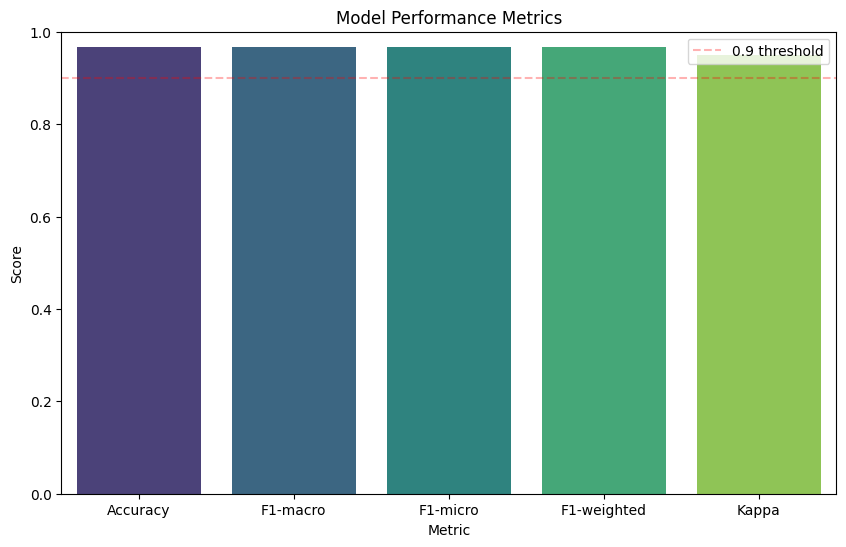

In [98]:
# Сравнение метрик в одном графике
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-macro', 'F1-micro', 'F1-weighted', 'Kappa'],
    'Score': [accuracy, f1_macro, f1_micro, f1_weighted, kappa]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Score', palette='viridis')
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.3, label='0.9 threshold')
plt.legend()
plt.show()

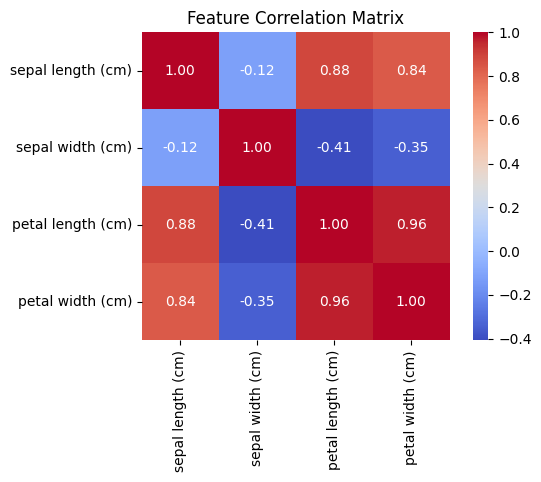

In [100]:
# Корреляционная матрица признаков
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(X_train,
                         columns=iris_dataset.feature_names).corr(),
                         annot=True,
                         fmt='.2f',
                         cmap='coolwarm',
                         square=True
)
plt.title('Feature Correlation Matrix')
plt.show()

#Кросс-валидация

In [118]:
#
# самый правильный способ проверить качество модели. позволяет избежать случайных "хороших" разиений
#
from sklearn.model_selection import StratifiedKFold, cross_val_score
scores_acc = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                             X_train,
                             y_train,
                             cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
)
print("Среднее значение правильности: {:.2f}".format(scores_acc.mean()))


Среднее значение правильности: 0.93


In [119]:
#
# точно такая же кросс-валидация, но дополнительно формируется cv_results, который потом можно анализировать
#
from sklearn.model_selection import cross_validate
cv_results = cross_validate(RandomForestClassifier(n_estimators=100, random_state=42),
                            X_train, y_train,
                            cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=0),
                            return_estimator=True,
                            scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
)


In [124]:
# ============================================
# 1. БАЗОВЫЙ ВИД: что содержится в cv_results
# ============================================
cv_results

{'fit_time': array([0.18710303, 0.1767447 , 0.18691969, 0.1746819 , 0.17297792,
        0.17218256, 0.17350316, 0.20181108, 0.16894674, 0.18053365]),
 'score_time': array([0.0199182 , 0.02168274, 0.02025986, 0.02190948, 0.02122426,
        0.02168298, 0.02164769, 0.02075982, 0.02148724, 0.02097988]),
 'estimator': [RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42),
  RandomForestClassifier(random_state=42)],
 'test_accuracy': array([1.        , 1.        , 0.83333333, 0.75      , 0.91666667,
        1.        , 0.91666667, 0.91666667, 1.        , 1.        ]),
 'test_f1_macro': array([1.        , 1.        , 0.82222222, 0.74603175, 0.91534392,
        1.    

In [126]:
print("\n" + "="*60)
print("ТАБЛИЦА МЕТРИК ПО ФОЛДАМ:")

# Определяем количество фолдов по длине любого массива метрик
n_folds = len(cv_results['test_accuracy'])

# Собираем все метрики автоматически
metrics_dict = {'Fold': range(1, n_folds + 1)}

# Добавляем все метрики, которые начинаются с 'test_'
for key in cv_results.keys():
    if key.startswith('test_'):
        # Убираем префикс 'test_' для названия колонки
        metric_name = key.replace('test_', '')
        metrics_dict[metric_name] = cv_results[key]

# Создаем DataFrame
metrics_df = pd.DataFrame(metrics_dict)

# Выводим с округлением до 3 знаков
print(metrics_df.round(3).to_string(index=False))


ТАБЛИЦА МЕТРИК ПО ФОЛДАМ:
 Fold  accuracy  f1_macro  precision_macro  recall_macro
    1     1.000     1.000            1.000         1.000
    2     1.000     1.000            1.000         1.000
    3     0.833     0.822            0.889         0.833
    4     0.750     0.746            0.756         0.750
    5     0.917     0.915            0.933         0.917
    6     1.000     1.000            1.000         1.000
    7     0.917     0.915            0.933         0.917
    8     0.917     0.915            0.933         0.917
    9     1.000     1.000            1.000         1.000
   10     1.000     1.000            1.000         1.000


In [127]:
# ============================================
# 3. СТАТИСТИКА ПО МЕТРИКАМ
# ============================================
print("\n" + "="*60)
print("СТАТИСТИКА ПО МЕТРИКАМ:")
stats_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-macro', 'Precision-macro', 'Recall-macro'],
    'Mean': [np.mean(cv_results['test_accuracy']),
             np.mean(cv_results['test_f1_macro']),
             np.mean(cv_results['test_precision_macro']),
             np.mean(cv_results['test_recall_macro'])],
    'Std': [np.std(cv_results['test_accuracy']),
            np.std(cv_results['test_f1_macro']),
            np.std(cv_results['test_precision_macro']),
            np.std(cv_results['test_recall_macro'])],
    'Min': [np.min(cv_results['test_accuracy']),
            np.min(cv_results['test_f1_macro']),
            np.min(cv_results['test_precision_macro']),
            np.min(cv_results['test_recall_macro'])],
    'Max': [np.max(cv_results['test_accuracy']),
            np.max(cv_results['test_f1_macro']),
            np.max(cv_results['test_precision_macro']),
            np.max(cv_results['test_recall_macro'])]
})
print(stats_df.to_string(index=False))


СТАТИСТИКА ПО МЕТРИКАМ:
         Metric     Mean      Std      Min  Max
       Accuracy 0.933333 0.081650 0.750000  1.0
       F1-macro 0.931429 0.084015 0.746032  1.0
Precision-macro 0.944444 0.073870 0.755556  1.0
   Recall-macro 0.933333 0.081650 0.750000  1.0


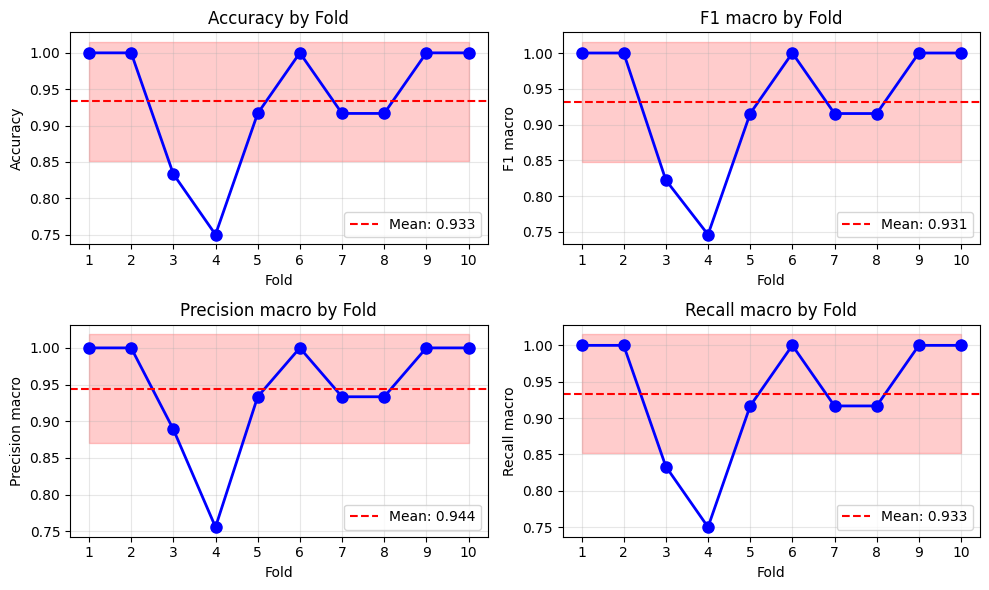

In [129]:
# ============================================
# 4. ВИЗУАЛИЗАЦИЯ: Сравнение метрик по фолдам (линейный график)
# ============================================
n_folds = len(cv_results['test_accuracy'])
metrics = [key for key in cv_results.keys() if key.startswith('test_')]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    values = cv_results[metric]
    title = metric.replace('test_', '').replace('_', ' ').capitalize()

    axes[i].plot(range(1, n_folds + 1), values, marker='o', linewidth=2, markersize=8, color='blue')
    axes[i].axhline(y=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
    axes[i].fill_between(range(1, n_folds + 1),
                         np.mean(values) - np.std(values),
                         np.mean(values) + np.std(values),
                         alpha=0.2, color='red')
    axes[i].set_xlabel('Fold')
    axes[i].set_ylabel(title)
    axes[i].set_title(f'{title} by Fold')
    axes[i].set_xticks(range(1, n_folds + 1))
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_722/1306917365.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(metrics_data, labels=['Accuracy', 'F1-macro', 'Precision-macro', 'Recall-macro'],


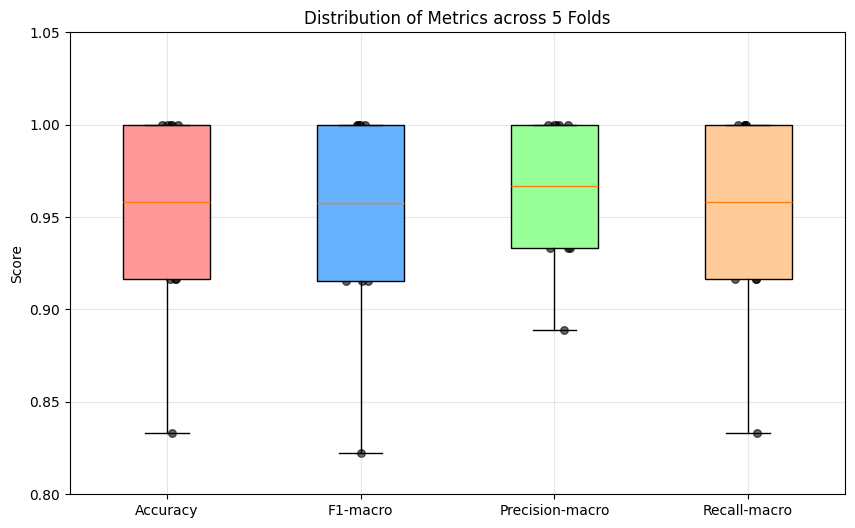

In [130]:
#  ============================================
# 5. ВИЗУАЛИЗАЦИЯ: Boxplot для сравнения метрик
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

metrics_data = [
    cv_results['test_accuracy'],
    cv_results['test_f1_macro'],
    cv_results['test_precision_macro'],
    cv_results['test_recall_macro']
]

box = ax.boxplot(metrics_data, labels=['Accuracy', 'F1-macro', 'Precision-macro', 'Recall-macro'],
                 patch_artist=True)

# Цвета для боксплотов
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score')
ax.set_title('Distribution of Metrics across 5 Folds')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 1.05)

# Добавляем точки для каждого фолда
for i, data in enumerate(metrics_data, 1):
    x = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.6, color='black', s=30)

plt.show()

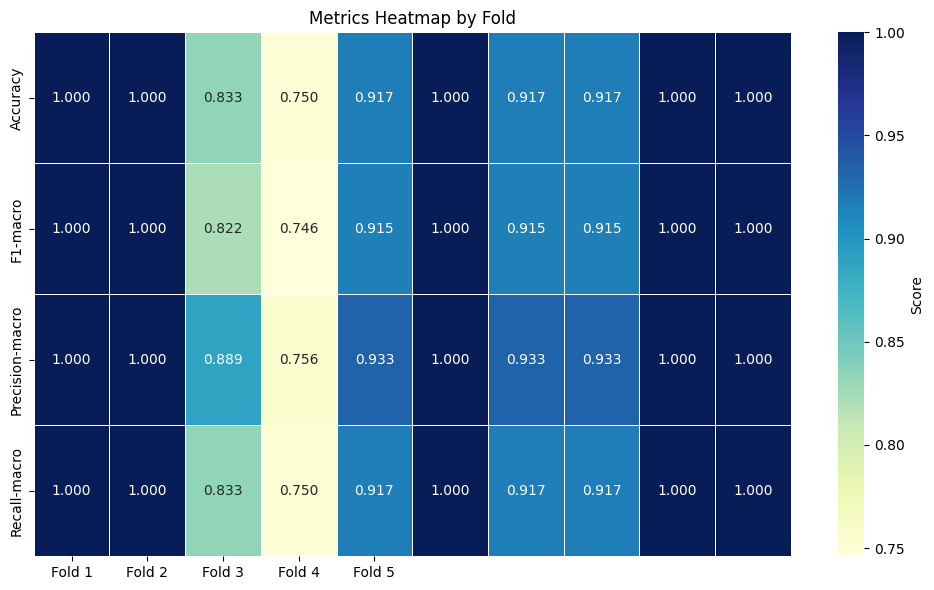

In [131]:
# ============================================
# 6. ВИЗУАЛИЗАЦИЯ: Heatmap метрик по фолдам
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Создаем матрицу для heatmap
heatmap_data = np.array([
    cv_results['test_accuracy'],
    cv_results['test_f1_macro'],
    cv_results['test_precision_macro'],
    cv_results['test_recall_macro']
])

sns.heatmap(heatmap_data,
            annot=True,
            fmt='.3f',
            cmap='YlGnBu',
            xticklabels=[f'Fold {i+1}' for i in range(5)],
            yticklabels=['Accuracy', 'F1-macro', 'Precision-macro', 'Recall-macro'],
            cbar_kws={'label': 'Score'},
            linewidths=0.5,
            linecolor='white')
plt.title('Metrics Heatmap by Fold')
plt.tight_layout()
plt.show()

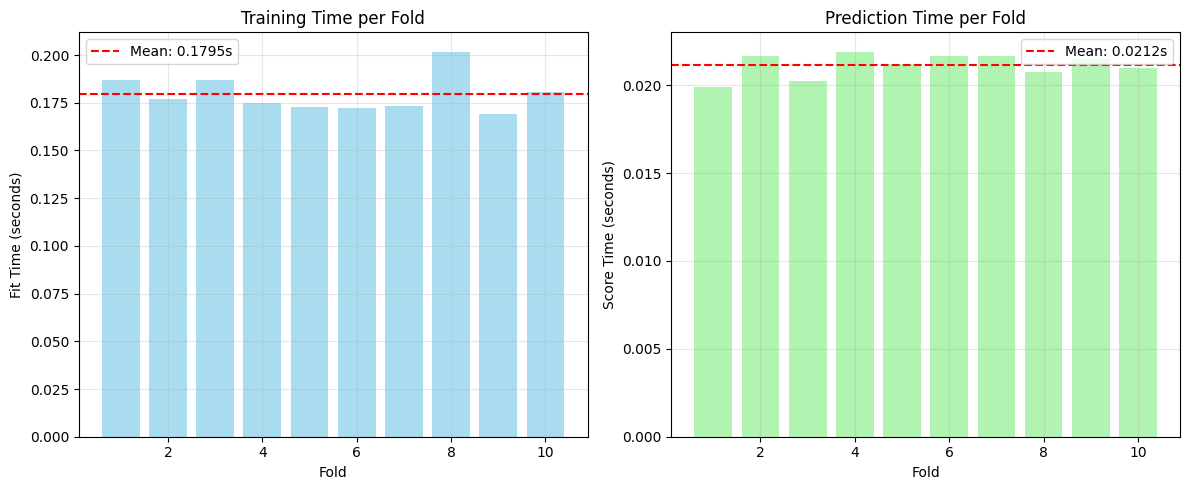

In [133]:
# ============================================
# 7. ВИЗУАЛИЗАЦИЯ: Сравнение моделей (время обучения)
# ============================================
if 'fit_time' in cv_results:
    n_folds = len(cv_results['fit_time'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Время обучения
    axes[0].bar(range(1, n_folds + 1), cv_results['fit_time'], color='skyblue', alpha=0.7)
    axes[0].axhline(y=np.mean(cv_results['fit_time']), color='red', linestyle='--',
                    label=f'Mean: {np.mean(cv_results["fit_time"]):.4f}s')
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('Fit Time (seconds)')
    axes[0].set_title('Training Time per Fold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Время предсказания
    if 'score_time' in cv_results:
        axes[1].bar(range(1, n_folds + 1), cv_results['score_time'], color='lightgreen', alpha=0.7)
        axes[1].axhline(y=np.mean(cv_results['score_time']), color='red', linestyle='--',
                       label=f'Mean: {np.mean(cv_results["score_time"]):.4f}s')
        axes[1].set_xlabel('Fold')
        axes[1].set_ylabel('Score Time (seconds)')
        axes[1].set_title('Prediction Time per Fold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [134]:
# ============================================
# 8. АНАЛИЗ МОДЕЛЕЙ: Изменение важности признаков
# ============================================
print("\n" + "="*60)
print("ИЗМЕНЧИВОСТЬ ВАЖНОСТИ ПРИЗНАКОВ ПО ФОЛДАМ:")

feature_importance_df = pd.DataFrame()
feature_importance_df['feature'] = X_train.columns

for i, estimator in enumerate(cv_results['estimator']):
    feature_importance_df[f'fold_{i+1}'] = estimator.feature_importances_

# Добавляем статистику
feature_importance_df['mean'] = feature_importance_df.iloc[:, 1:6].mean(axis=1)
feature_importance_df['std'] = feature_importance_df.iloc[:, 1:6].std(axis=1)
feature_importance_df = feature_importance_df.sort_values('mean', ascending=False)

print(feature_importance_df.to_string(index=False))


ИЗМЕНЧИВОСТЬ ВАЖНОСТИ ПРИЗНАКОВ ПО ФОЛДАМ:
          feature   fold_1   fold_2   fold_3   fold_4   fold_5   fold_6   fold_7   fold_8   fold_9  fold_10     mean      std
petal length (cm) 0.442233 0.456464 0.481050 0.469343 0.417575 0.458092 0.461125 0.448036 0.454970 0.449916 0.453333 0.024679
 petal width (cm) 0.407773 0.391420 0.393690 0.381371 0.438174 0.386120 0.392514 0.404491 0.396449 0.398903 0.402486 0.022064
sepal length (cm) 0.115593 0.125888 0.106359 0.126313 0.114600 0.130121 0.117192 0.123754 0.123568 0.122292 0.117751 0.008424
 sepal width (cm) 0.034401 0.026228 0.018901 0.022973 0.029650 0.025666 0.029169 0.023719 0.025013 0.028889 0.026431 0.005970


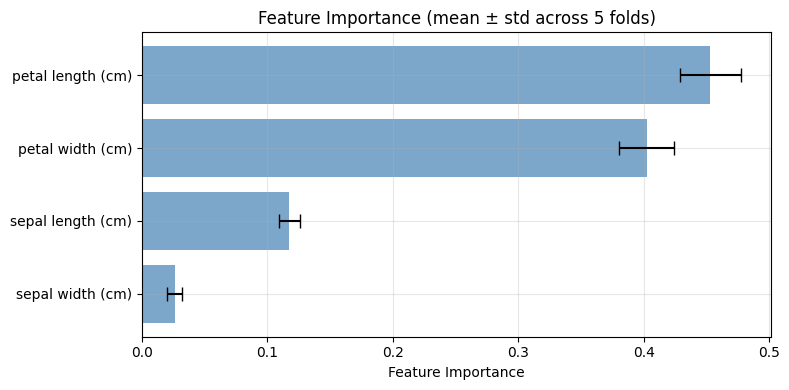

In [136]:
# ============================================
# 9. ВИЗУАЛИЗАЦИЯ: Важность признаков с ошибками
# ============================================
fig, ax = plt.subplots(figsize=(8, 4))

y_pos = np.arange(len(feature_importance_df))
ax.barh(y_pos, feature_importance_df['mean'],
        xerr=feature_importance_df['std'],
        align='center',
        alpha=0.7,
        color='steelblue',
        capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_importance_df['feature'])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance (mean ± std across 5 folds)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

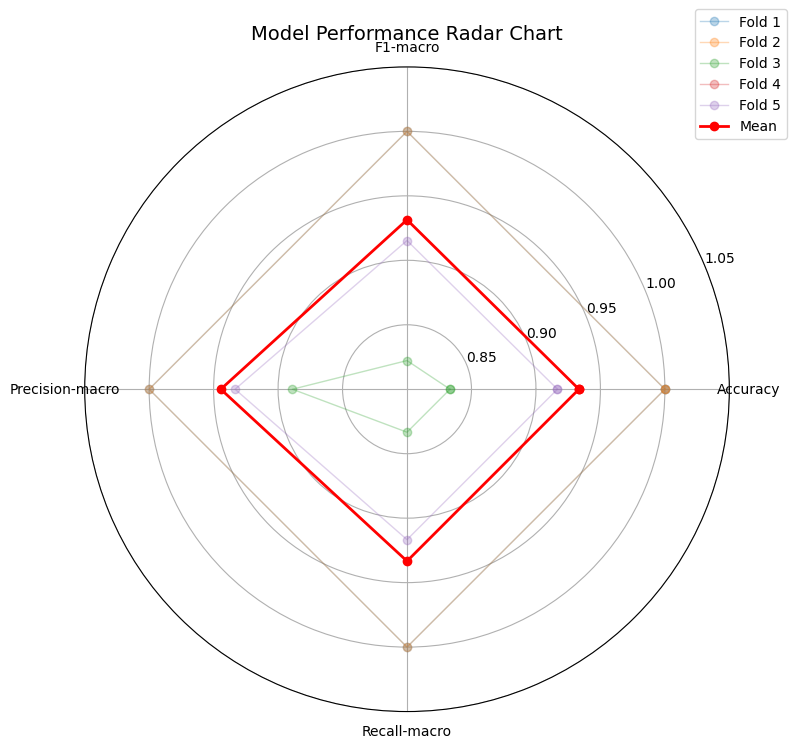

In [137]:
#  ============================================
# 10. ВИЗУАЛИЗАЦИЯ: Радарная диаграмма (паутинка)
# ============================================
from math import pi

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Усредненные метрики
metrics_avg = [
    np.mean(cv_results['test_accuracy']),
    np.mean(cv_results['test_f1_macro']),
    np.mean(cv_results['test_precision_macro']),
    np.mean(cv_results['test_recall_macro'])
]

# Добавляем метрики для каждого фолда
angles = [n / float(4) * 2 * pi for n in range(4)]
angles += angles[:1]  # Замыкаем круг

# Рисуем для каждого фолда
for fold in range(5):
    values = [
        cv_results['test_accuracy'][fold],
        cv_results['test_f1_macro'][fold],
        cv_results['test_precision_macro'][fold],
        cv_results['test_recall_macro'][fold]
    ]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1, alpha=0.3, label=f'Fold {fold+1}')

# Рисуем средние значения
avg_values = metrics_avg + metrics_avg[:1]
ax.plot(angles, avg_values, 'o-', linewidth=2, color='red', label='Mean')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Accuracy', 'F1-macro', 'Precision-macro', 'Recall-macro'])
ax.set_ylim(0.8, 1.05)
ax.set_title('Model Performance Radar Chart', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

In [138]:
# ============================================
# 11. ВЫВОД ИТОГОВОЙ СТАТИСТИКИ
# ============================================
print("\n" + "="*60)
print("ИТОГОВАЯ СТАТИСТИКА ПО КРОСС-ВАЛИДАЦИИ:")
print("="*60)
print(f"Accuracy:  {np.mean(cv_results['test_accuracy']):.4f} ± {np.std(cv_results['test_accuracy']):.4f}")
print(f"F1-macro:  {np.mean(cv_results['test_f1_macro']):.4f} ± {np.std(cv_results['test_f1_macro']):.4f}")
print(f"Precision: {np.mean(cv_results['test_precision_macro']):.4f} ± {np.std(cv_results['test_precision_macro']):.4f}")
print(f"Recall:    {np.mean(cv_results['test_recall_macro']):.4f} ± {np.std(cv_results['test_recall_macro']):.4f}")

if 'fit_time' in cv_results:
    print(f"\nFit time:   {np.mean(cv_results['fit_time']):.4f} ± {np.std(cv_results['fit_time']):.4f} seconds")
if 'score_time' in cv_results:
    print(f"Score time: {np.mean(cv_results['score_time']):.4f} ± {np.std(cv_results['score_time']):.4f} seconds")


ИТОГОВАЯ СТАТИСТИКА ПО КРОСС-ВАЛИДАЦИИ:
Accuracy:  0.9333 ± 0.0816
F1-macro:  0.9314 ± 0.0840
Precision: 0.9444 ± 0.0739
Recall:    0.9333 ± 0.0816

Fit time:   0.1795 ± 0.0094 seconds
Score time: 0.0212 ± 0.0006 seconds
